/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression : 0.0
Decision Tree : 0.0
Random Forest : 0.0


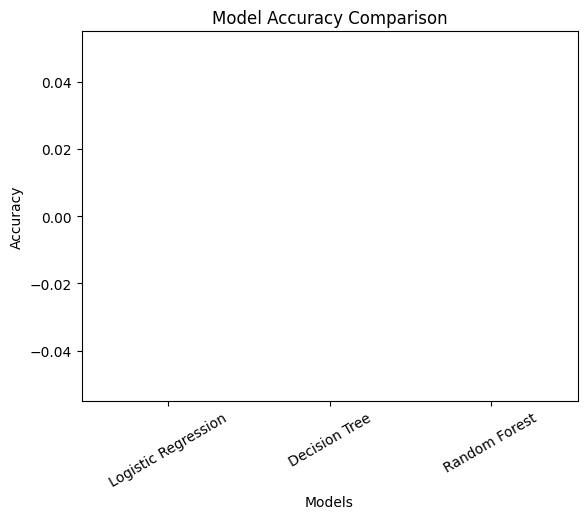

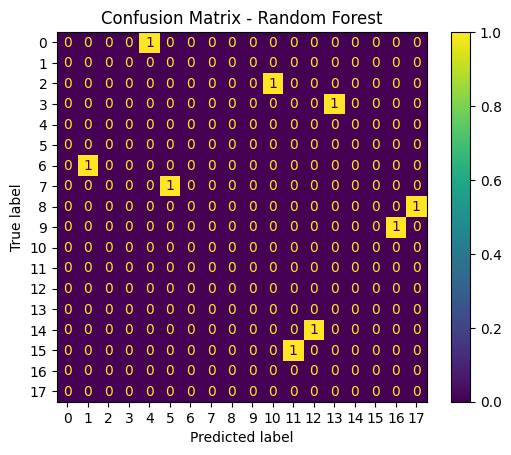

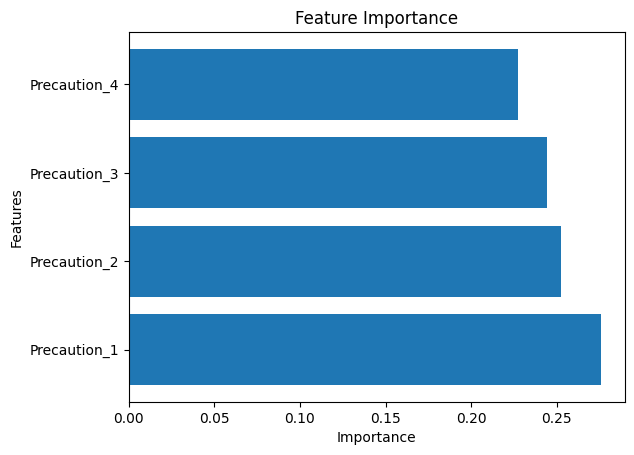

In [3]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ==============================
# STEP 2: LOAD DATA
# ==============================
df = pd.read_csv('/content/medicine_dataset.csv')

# ==============================
# STEP 3: PREPROCESSING
# ==============================
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

# ==============================
# STEP 4: FEATURES & TARGET
# ==============================
X = df.drop(['Disease', 'Unnamed: 0'], axis=1)
y = df['Disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

results = {}

# ==============================
# 1. LOGISTIC REGRESSION
# ==============================
log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)
pred_log = log.predict(X_test)
acc_log = accuracy_score(y_test, pred_log)
results['Logistic Regression'] = acc_log

# ==============================
# 2. DECISION TREE
# ==============================
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt)
results['Decision Tree'] = acc_dt

# ==============================
# 3. RANDOM FOREST
# ==============================
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
results['Random Forest'] = acc_rf

# ==============================
# PRINT RESULTS
# ==============================
for model, acc in results.items():
    print(model, ":", acc)

# ==============================
# GRAPH 1: MODEL ACCURACY
# ==============================
models = list(results.keys())
accuracy = list(results.values())

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

# ==============================
# GRAPH 2: CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ==============================
# GRAPH 3: FEATURE IMPORTANCE
# ==============================
importances = rf.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()